# Lab 17
**Author**: The Tuan Trinh \
**Date**: 28/06/2026

In [1]:
import os
import platform
print("=" * 100)
print("OS Name:", os.name)
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())
print("Platform:", platform.platform())

print("\nEnvironment Variables (sample):")
for key, value in list(os.environ.items())[:15]:
    print(f"{key} = {value}")

OS Name: nt
System: Windows
Release: 10
Machine: AMD64
Processor: Intel64 Family 6 Model 142 Stepping 12, GenuineIntel
Platform: Windows-10-10.0.26200-SP0

Environment Variables (sample):
ALLUSERSPROFILE = C:\ProgramData
APPDATA = C:\Users\tuan.trinhthe\AppData\Roaming
COMMONPROGRAMFILES = C:\Program Files\Common Files
COMMONPROGRAMFILES(X86) = C:\Program Files (x86)\Common Files
COMMONPROGRAMW6432 = C:\Program Files\Common Files
COMPUTERNAME = TH202601
COMSPEC = C:\WINDOWS\system32\cmd.exe
CONDA_DEFAULT_ENV = PMH
CONDA_EXE = C:\Users\tuan.trinhthe\AppData\Local\miniconda3\Scripts\conda.exe
CONDA_EXES = "C:\Users\tuan.trinhthe\AppData\Local\miniconda3\condabin\..\Scripts\conda.exe"  
CONDA_PREFIX = C:\Users\tuan.trinhthe\AppData\Local\miniconda3\envs\PMH
CONDA_PROMPT_MODIFIER = (PMH) 
CONDA_PYTHON_EXE = C:\Users\tuan.trinhthe\AppData\Local\miniconda3\python.exe
CONDA_ROOT = C:\Users\tuan.trinhthe\AppData\Local\miniconda3
CONDA_SHLVL = 1


In [2]:
platform.python_version()

'3.10.20'

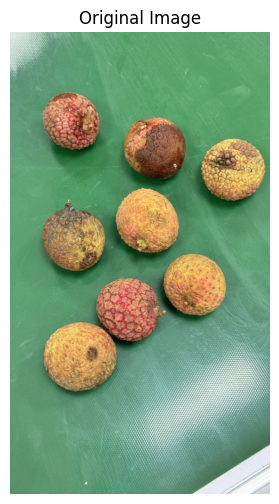

In [3]:
import numpy as np
import cv2 as cv
from matplotlib import pyplot as plt

img = cv.imread('lychee.jpg')
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
plt.figure(figsize=(8, 6))
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis("off")
assert img is not None, "file could not be read, check with os.path.exists()"

Otsu Threshold Value: 161.0


(np.float64(-0.5), np.float64(1439.5), np.float64(2559.5), np.float64(-0.5))

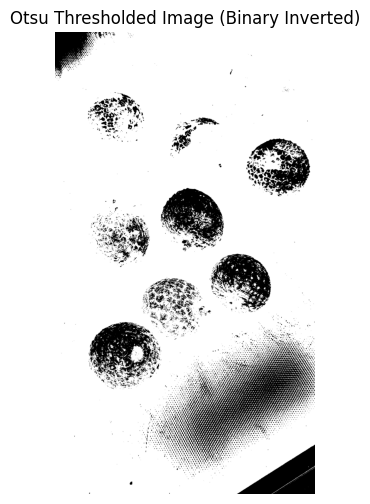

In [4]:
# Grayscale conversion and Otsu's thresholding
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
ret, thresh = cv.threshold(gray, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
print("Otsu Threshold Value:", ret)

plt.figure(figsize=(8, 6))
plt.imshow(thresh, cmap='gray')
plt.title('Otsu Thresholded Image (Binary Inverted)')
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(2559.5), np.float64(-0.5))

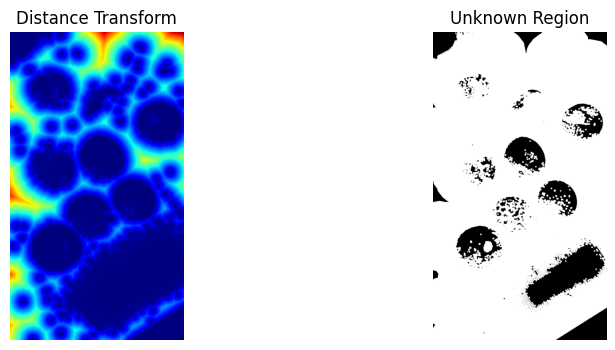

In [ ]:
kernel = np.ones((3,3), np.uint8)
opening = cv.morphologyEx(thresh, cv.MORPH_OPEN, kernel, iterations=2)
sure_bg = cv.dilate(opening, kernel, iterations=3)
dist_transform = cv.distanceTransform(opening, cv.DIST_L2, 5)
ret_fg, sure_fg = cv.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)
unknown = cv.subtract(sure_bg, sure_fg)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(dist_transform, cmap='jet')
plt.title('Distance Transform')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(unknown, cmap='gray')
plt.title('Unknown Region')
plt.axis("off")

(np.float64(-0.5), np.float64(1439.5), np.float64(2559.5), np.float64(-0.5))

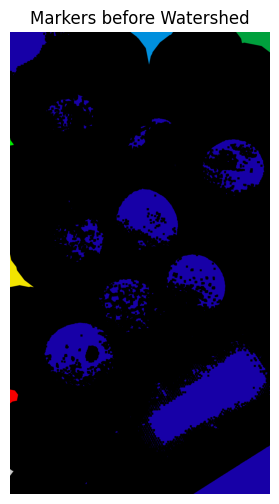

In [ ]:
ret_markers, markers = cv.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0
plt.figure(figsize=(8, 6))
plt.imshow(markers, cmap='nipy_spectral')
plt.title('Markers before Watershed')
plt.axis("off")

Lychee Count (Lab 11 Method): 6


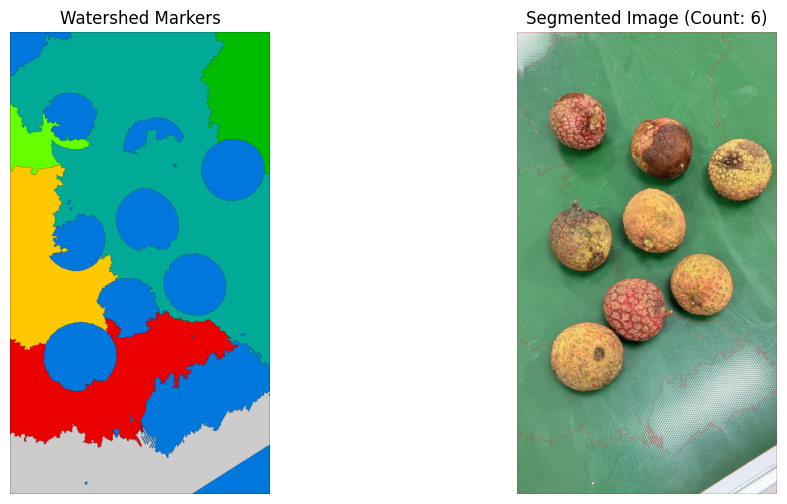

In [ ]:
markers_ws = cv.watershed(img.copy(), markers.copy())
img_ws = img_rgb.copy()
img_ws[markers_ws == -1] = [255, 0, 0]  # Red boundaries in RGB

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(markers_ws, cmap='nipy_spectral')
plt.title('Watershed Markers')
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img_ws)
plt.title(f'Segmented Image (Count: {ret_markers - 1})')
plt.axis("off")

print("Lychee Count (Lab 11 Method):", ret_markers - 1)

In [ ]:
scales = [0.1, 0.25, 0.5, 1.0, 1.5]
for scale in scales:
    w = int(img.shape[1] * scale)
    h = int(img.shape[0] * scale)
    resized = cv.resize(img, (w, h), interpolation=cv.INTER_AREA if scale < 1.0 else cv.INTER_CUBIC)
    
    gray_resized = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    _, thresh_resized = cv.threshold(gray_resized, 0, 255, cv.THRESH_BINARY_INV + cv.THRESH_OTSU)
    
    kernel_r = np.ones((3,3), np.uint8)
    opening_r = cv.morphologyEx(thresh_resized, cv.MORPH_OPEN, kernel_r, iterations=2)
    sure_bg_r = cv.dilate(opening_r, kernel_r, iterations=3)
    
    dist_r = cv.distanceTransform(opening_r, cv.DIST_L2, 5)
    max_d = dist_r.max()
    _, sure_fg_r = cv.threshold(dist_r, 0.7 * max_d if max_d > 0 else 0, 255, 0)
    sure_fg_r = np.uint8(sure_fg_r)
    
    _, markers_r = cv.connectedComponents(sure_fg_r)
    count = markers_r.max()
    print(f"{scale:<6.2f} | {f'{w}x{h}':<12} | {max_d:<10.2f} | {count:<6}")

In [ ]:
def count_lychees_robust(image, scale=1.0, verbose=False):
    hsv = cv.cvtColor(image, cv.COLOR_BGR2HSV)

    lower_red1 = np.array([0, 40, 40])
    upper_red1 = np.array([22, 255, 255])
    lower_red2 = np.array([165, 40, 40])
    upper_red2 = np.array([180, 255, 255])
    
    mask1 = cv.inRange(hsv, lower_red1, upper_red1)
    mask2 = cv.inRange(hsv, lower_red2, upper_red2)
    lychee_mask = cv.bitwise_or(mask1, mask2)
    k_size = max(3, int(5 * scale))
    if k_size % 2 == 0:
        k_size += 1
    kernel = np.ones((k_size, k_size), np.uint8)
    opening = cv.morphologyEx(lychee_mask, cv.MORPH_OPEN, kernel, iterations=2)
    filled = np.zeros_like(opening)
    contours, _ = cv.findContours(opening, cv.RETR_CCOMP, cv.CHAIN_APPROX_SIMPLE)
    for i in range(len(contours)):
        cv.drawContours(filled, contours, i, 255, -1)
    sure_bg = cv.dilate(filled, kernel, iterations=3)
    dist_transform = cv.distanceTransform(filled, cv.DIST_L2, 5)
    max_dist = dist_transform.max()
    _, sure_fg = cv.threshold(dist_transform, 0.5 * max_dist if max_dist > 0 else 0, 255, 0)
    sure_fg = np.uint8(sure_fg)
    unknown = cv.subtract(sure_bg, sure_fg)
    ret_markers, markers = cv.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    markers_ws = cv.watershed(image, markers.copy())
    num_labels, labels, stats, centroids = cv.connectedComponentsWithStats(sure_fg)
    min_area = max(10, int(1000 * (scale ** 2)))
    
    final_count = 0
    for i in range(1, num_labels):
        if stats[i, cv.CC_STAT_AREA] >= min_area:
            final_count += 1
            
    if verbose:
        plt.figure(figsize=(15, 10))
        
        plt.subplot(2, 3, 1)
        plt.imshow(cv.cvtColor(image, cv.COLOR_BGR2RGB))
        plt.title('Original Image')
        plt.axis('off')
        
        plt.subplot(2, 3, 2)
        plt.imshow(lychee_mask, cmap='gray')
        plt.title('HSV Red Mask')
        plt.axis('off')
        
        plt.subplot(2, 3, 3)
        plt.imshow(filled, cmap='gray')
        plt.title('Holes Filled Mask')
        plt.axis('off')
        
        plt.subplot(2, 3, 4)
        plt.imshow(dist_transform, cmap='jet')
        plt.title('Distance Transform')
        plt.axis('off')
        
        plt.subplot(2, 3, 5)
        plt.imshow(markers_ws, cmap='nipy_spectral')
        plt.title('Watershed Markers')
        plt.axis('off')
        
        img_result = cv.cvtColor(image, cv.COLOR_BGR2RGB)
        img_result[markers_ws == -1] = [255, 0, 0]
        plt.subplot(2, 3, 6)
        plt.imshow(img_result)
        plt.title(f'Final Count: {final_count}')
        plt.axis('off')
        
        plt.tight_layout()
        plt.show()
        
    return final_count

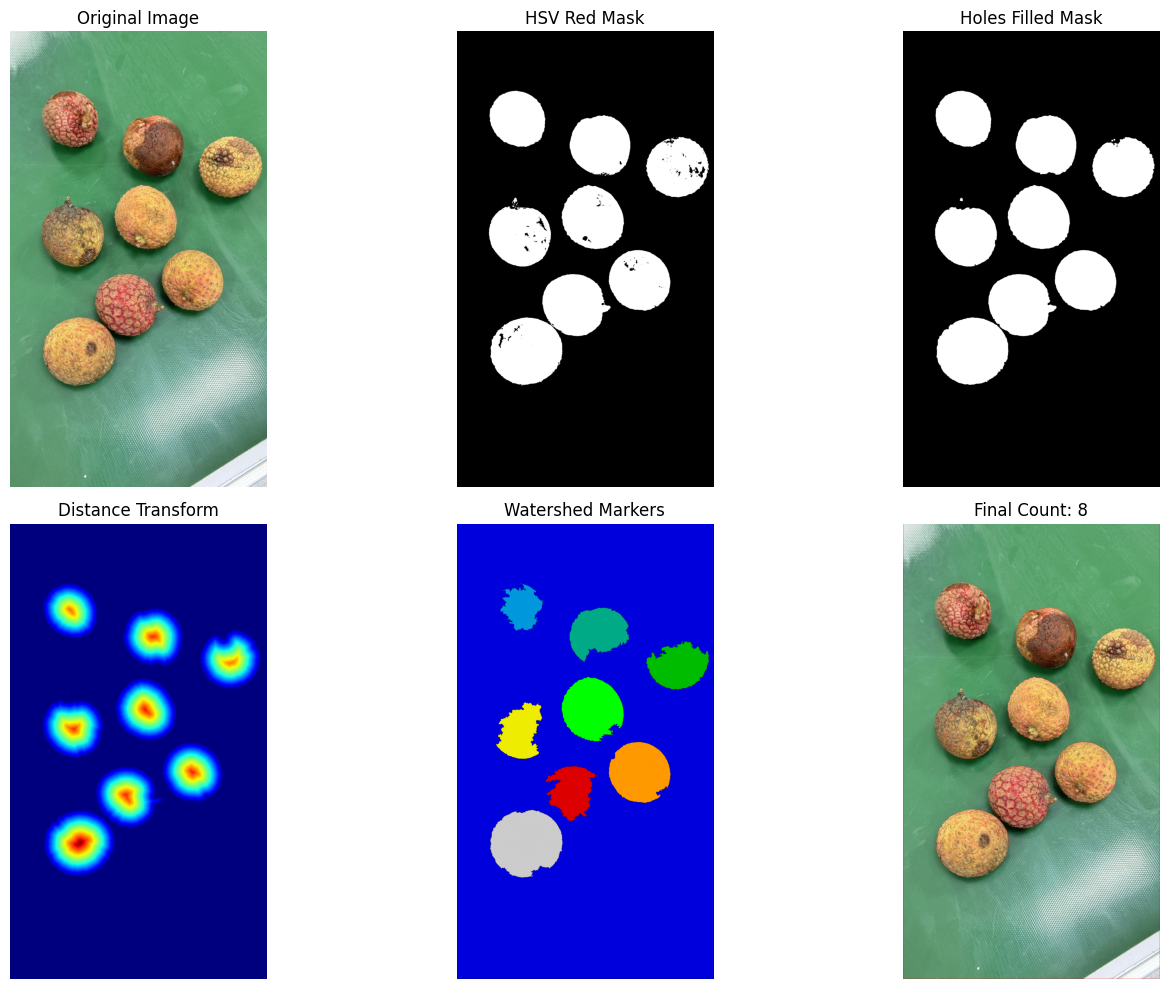

Robust lychee count at original scale: 8


In [ ]:
count_orig = count_lychees_robust(img, scale=1.0, verbose=True)
print("Robust lychee count at original scale:", count_orig)